# Lab 02: Thuật toán Gradient Descent
**Mục tiêu:**
- Hiểu cách hoạt động của thuật toán Gradient Descent.
- Triển khai thuật toán Gradient Descent và trực quan hóa quá trình hội tụ.
- Thực hành với các hàm có độ cong khác nhau để quan sát ảnh hưởng đến quá trình hội tụ.
- Hiểu về ảnh hưởng của tốc độ học (learning rate) và điểm khởi đầu (initial point) đến quá trình hội tụ.
- Nhận biết các vấn đề phổ biến như hội tụ chậm, không hội tụ, và cách khắc phục chúng.

## 1. Gradient Descent trên hàm 2 biến
Áp dụng thuật toán Gradient Descent để tìm cực tiểu của hàm: $f(x, y) = x^2 + y^2$
- Điểm bắt đầu: $(x_0 = -2, y_0 = 2)$
- Tốc độ học: $\alpha = 0.1$
- Số lần lặp: $K = 10$


In [1]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import thư viện
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib widget

In [3]:
# Định nghĩa hàm số và gradient
def f1(x, y):
    return x**2 + y**2

def grad_f1(x, y):
    return np.array([2*x, 2*y])

In [4]:
# Tìm điểm cực tiểu dùng Sympy
def compute_local_minima(f):
    x, y = sp.symbols('x y')
    
    # Gradient
    grad = [f.diff(var) for var in (x, y)]
    equations = [sp.Eq(g, 0) for g in grad]
    
    # Giải hệ ∇f = 0
    solutions = sp.solve(equations, (x, y), dict=True)
    
    # Ma trận Hessian
    H = sp.Matrix([[f.diff(x, x), f.diff(x, y)],
                   [f.diff(y, x), f.diff(y, y)]])
    
    minima_points = []
    
    for sol in solutions:
        x_val = sol[x]
        y_val = sol[y]
        
        # Chỉ xét nghiệm thực
        if abs(sp.im(x_val)) < 1e-8 and abs(sp.im(y_val)) < 1e-8:
            x_real = float(sp.re(x_val))
            y_real = float(sp.re(y_val))
            
            # Đánh giá Hessian tại điểm
            H_val = H.subs({x: x_real, y: y_real})
            det_H = H_val.det()
            trace_H = H_val.trace()
            
            # Cực tiểu: Hessian dương định nghĩa (det>0, trace>0)
            if det_H > 0 and trace_H > 0:
                minima_points.append((x_real, y_real))
    
    return minima_points

In [5]:
# Cài đặt Gradient Descent
def gradient_descent(f, grad_f, lr=0.1, max_iters=50, initial_w=np.array([1.0, 1.0]), verbose=False):
    weight_history = [initial_w.copy()]
    loss_history = [f(initial_w[0], initial_w[1])]
    w = initial_w.copy()
    
    for _ in range(max_iters):
        g = grad_f(w[0], w[1])
        w = w - lr * g
        weight_history.append(w.copy())
        loss_history.append(f(w[0], w[1]))

    # In ra bảng kết quả
    if verbose:
        header = f"{'Iteration':>9} | {'w1':>10} | {'w2':>10} | {'grad_w1':>10} | {'grad_w2':>10} | {'Loss':>10}"
        print(header)
        print("-"*80)
        for i in range(len(weight_history)):
            w = weight_history[i]
            g = grad_f(w[0], w[1])
            print(f"{i:9d} | {w[0]:10.6f} | {w[1]:10.6f} | {g[0]:10.6f} | {g[1]:10.6f} | {loss_history[i]:10.6f}")

    return np.array(weight_history), np.array(loss_history)

In [6]:
# Hàm vẽ quá trình GD trên contour
def plot_gd_contour(f, weight_history, limits=(-4, 4), levels=50, contour_cmap="Blues", path_cmap="plasma", f_sym=None):
    # Vẽ contour của hàm
    x = np.linspace(limits[0], limits[1], 100)
    y = np.linspace(limits[0], limits[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)
    plt.figure(figsize=(7,7))
    plt.contourf(X, Y, Z, levels=levels, cmap=contour_cmap, alpha=0.6)

    # Vẽ đường contour
    c = plt.contour(X, Y, Z, levels=levels, colors="black", linewidths=0.6)
    plt.clabel(c, inline=True, fontsize=8, fmt="%.1f")
    
    # Vẽ quỹ đạo GD trên contour với màu đổi
    cmap = plt.get_cmap(path_cmap)
    for i in range(len(weight_history)-1):
        plt.plot(weight_history[i,0], weight_history[i,1], 'o', color=cmap(i/len(weight_history)), markersize=7)
        plt.annotate('', xy=weight_history[i+1], xytext=weight_history[i],
                     arrowprops=dict(arrowstyle='->', color=cmap(i/len(weight_history)), lw=1.5))
    
    # Vẽ điểm cuối cùng
    plt.plot(weight_history[-1,0], weight_history[-1,1], 'o', color=cmap(1.0), markersize=7)

    # Tìm và vẽ tất cả các điểm cực tiểu của f
    if f_sym is not None:
        minima_points = compute_local_minima(f_sym)
        #print("Critical points:", minima_points)
        for cp in minima_points:
            plt.scatter(cp[0], cp[1], s=100, color='red', marker='x', zorder=7)

    plt.title("Gradient Descent")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

In [7]:
# Hàm vẽ quá trình GD trên 3D (surface)
def plot_gd_3d(f, weight_history, loss_history, limits=(-4, 4), surface_cmap="viridis", path_cmap="plasma"):

    # Vẽ surface của hàm
    x = np.linspace(limits[0], limits[1], 100)
    y = np.linspace(limits[0], limits[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=surface_cmap, alpha=0.6)

    # Vẽ quỹ đạo GD trên surface với màu đổi
    cmap = plt.get_cmap(path_cmap)
    
    # Vẽ đường nối các điểm
    #ax.plot(weight_history[:,0], weight_history[:,1], loss_history, color='black', linewidth=2, alpha=0.8, label='GD Path')
    
    # Vẽ các điểm (trừ điểm cuối) và mũi tên
    for i in range(len(weight_history)-1):
        # Vẽ điểm hiện tại
        ax.scatter(weight_history[i,0], weight_history[i,1], loss_history[i], color=cmap(i/len(weight_history)), s=50, alpha=0.9)
        
        # Vẽ mũi tên 3D từ điểm i đến điểm i+1
        ax.quiver(weight_history[i,0], weight_history[i,1], loss_history[i],
                 weight_history[i+1,0] - weight_history[i,0], weight_history[i+1,1] - weight_history[i,1], loss_history[i+1] - loss_history[i],
                 color=cmap(i/len(weight_history)), arrow_length_ratio=0.1, linewidth=2, alpha=0.8)
    
    # Vẽ điểm cuối cùng
    ax.scatter(weight_history[-1,0], weight_history[-1,1], loss_history[-1], color=cmap(1.0), s=50, alpha=0.9)

    ax.set_title("Gradient Descent on Surface")
    ax.set_xlabel("X axis")
    ax.set_ylabel("Y axis")
    ax.set_zlabel("f(x,y)")
    plt.show()

In [8]:
# Chạy GD
w_hist, loss_hist = gradient_descent(f1, grad_f1, lr=0.1, max_iters=5, initial_w=np.array([-2, 2]), verbose=True)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |  -2.000000 |   2.000000 |  -4.000000 |   4.000000 |   8.000000
        1 |  -1.600000 |   1.600000 |  -3.200000 |   3.200000 |   5.120000
        2 |  -1.280000 |   1.280000 |  -2.560000 |   2.560000 |   3.276800
        3 |  -1.024000 |   1.024000 |  -2.048000 |   2.048000 |   2.097152
        4 |  -0.819200 |   0.819200 |  -1.638400 |   1.638400 |   1.342177
        5 |  -0.655360 |   0.655360 |  -1.310720 |   1.310720 |   0.858993


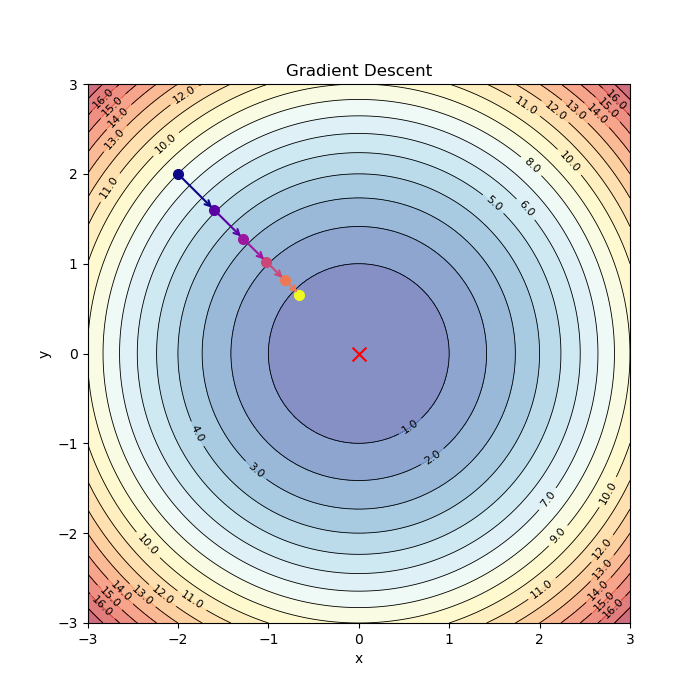

In [9]:
# Vẽ quá trình GD trên contour
x, y = sp.symbols('x y')
f_sym = 0.5*(x**2 + y**2)
plot_gd_contour(f1, w_hist, limits=(-3, 3), levels=20, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)

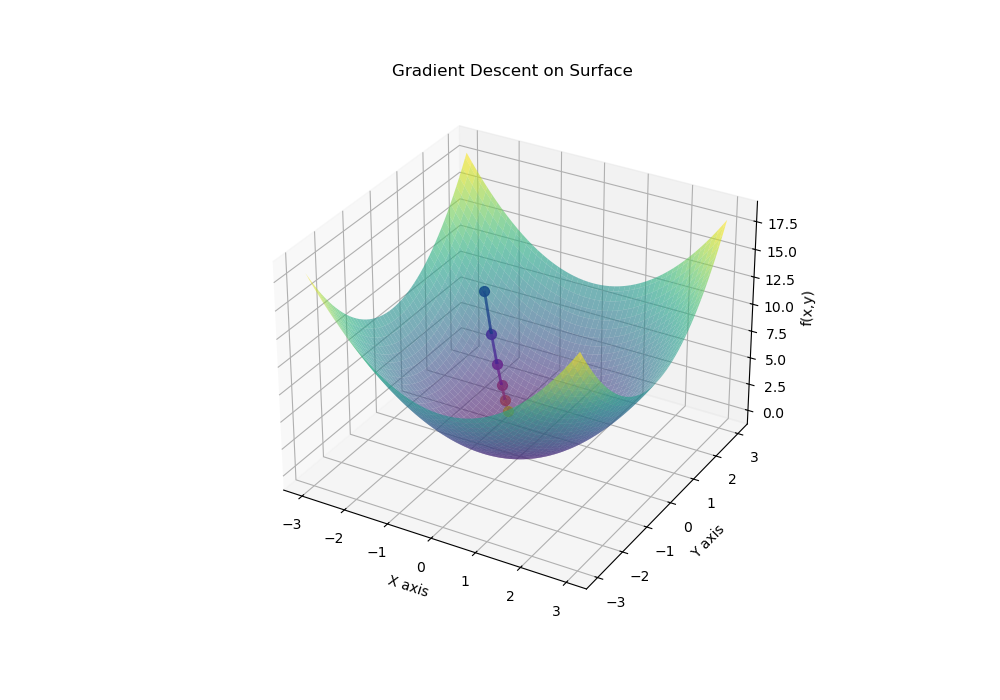

In [10]:
# Vẽ quá trình GD trên 3D
plot_gd_3d(f1, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")

## 2. Gradient Descent trên hàm 2 biến có độ cong khác nhau
Áp dụng thuật toán Gradient Descent để tìm cực tiểu của hàm: $f(x,y)= \frac{1}{2}[(x^4 - 16x^2 + 5x) + (y^4 - 16y^2 + 5y)]$
- Tốc độ học: $\alpha = 0.02$
- Số lần lặp: $K = 10$ 
- Thực nghiệm với một số điểm bắt đầu khác nhau và nhận xét sự khác biệt trong quá trình hội tụ.
    - Điểm bắt đầu: $(0.5, -1)$
    - Điểm bắt đầu: $(-1, 1)$
    - Điểm bắt đầu: $(0.5, 1)$
    - Điểm bắt đầu: $(-3, 0)$
    - Điểm bắt đầu: $(-3, 0.3)$

In [11]:
def f2(x, y):
    return 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
def grad_f2(x, y):
    df_dx = 0.5*(4*x**3 - 32*x + 5)
    df_dy = 0.5*(4*y**3 - 32*y + 5)
    return np.array([df_dx, df_dy])

In [12]:
# chay gd
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr=0.02, max_iters=10, initial_w=np.array([0.5, -1]), verbose=True)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |   0.500000 |  -1.000000 |  -5.250000 |  16.500000 | -10.718750
        1 |   0.605000 |  -1.330000 |  -6.737110 |  19.074726 | -17.260409
        2 |   0.739742 |  -1.711495 |  -8.526274 |  19.857247 | -25.800967
        3 |   0.910268 |  -2.108639 | -10.555810 |  17.486690 | -34.967172
        4 |   1.121384 |  -2.458373 | -12.621858 |  12.119128 | -42.698080
        5 |   1.373821 |  -2.700756 | -14.295280 |   6.313025 | -48.386141
        6 |   1.659727 |  -2.827016 | -14.911553 |   2.545113 | -53.161567
        7 |   1.957958 |  -2.877919 | -13.815276 |   0.874464 | -57.580572
        8 |   2.234263 |  -2.895408 | -10.941631 |   0.279879 | -61.055133
        9 |   2.453096 |  -2.901005 |  -7.225646 |   0.087336 | -63.068518
       10 |   2.597609 |  -2.902752 |  -4.006640 |   0.027030 | -63.887844


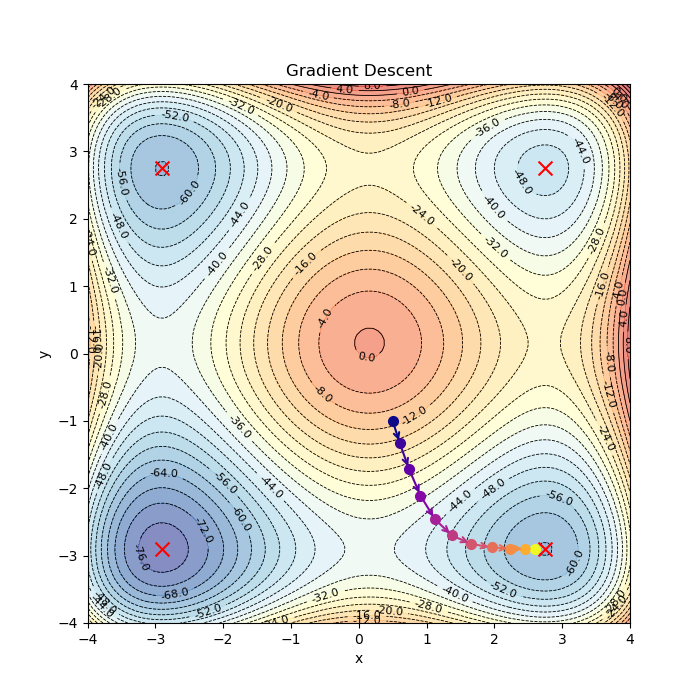

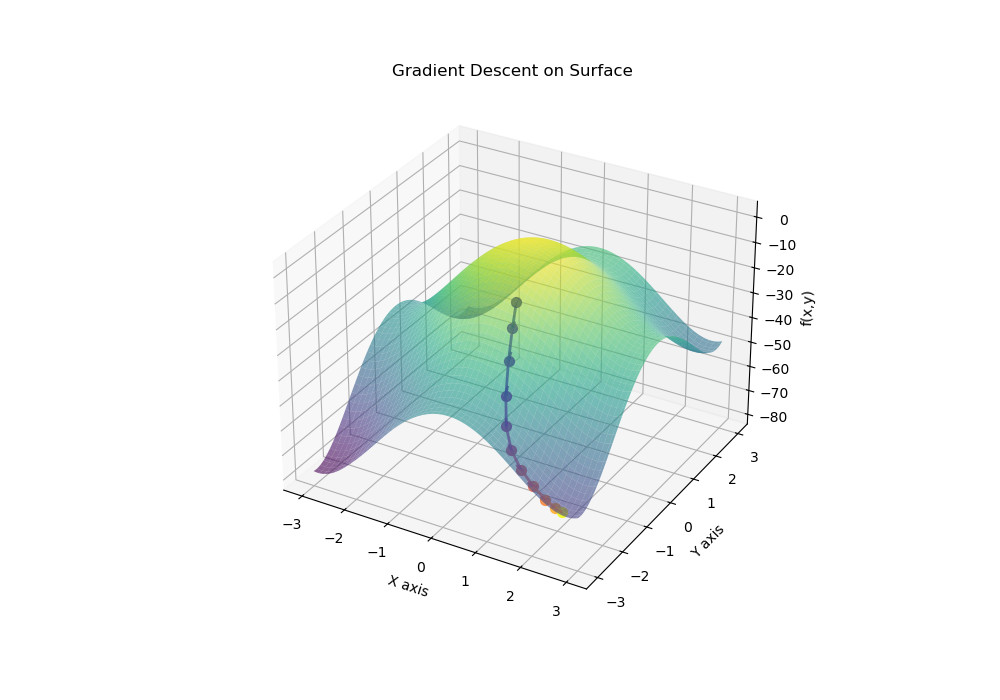

In [13]:
# Vẽ quá trình GD trên contour
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
# ve qua trinh gd tren 3d
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")


x, y = (-1, 1)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |  -1.000000 |   1.000000 |  16.500000 | -11.500000 | -15.000000
        1 |  -1.330000 |   1.230000 |  19.074726 | -13.458266 | -23.795463
        2 |  -1.711495 |   1.499165 |  19.857247 | -14.747907 | -35.128738
        3 |  -2.108639 |   1.794123 |  17.486690 | -14.655843 | -47.042554
        4 |  -2.458373 |   2.087240 |  12.119128 | -12.709419 | -56.376797
        5 |  -2.700756 |   2.341429 |   6.313025 |  -9.290085 | -61.479722
        6 |  -2.827016 |   2.527230 |   2.545113 |  -5.653384 | -63.448377
        7 |  -2.877919 |   2.640298 |   0.874464 |  -2.932815 | -64.024930
        8 |  -2.895408 |   2.698954 |   0.279879 |  -1.362988 | -64.161567
        9 |  -2.901005 |   2.726214 |   0.087336 |  -0.595652 | -64.189346
       10 |  -2.902752 |   2.738127 |   0.027030 |  -0.252692 | -64.194504


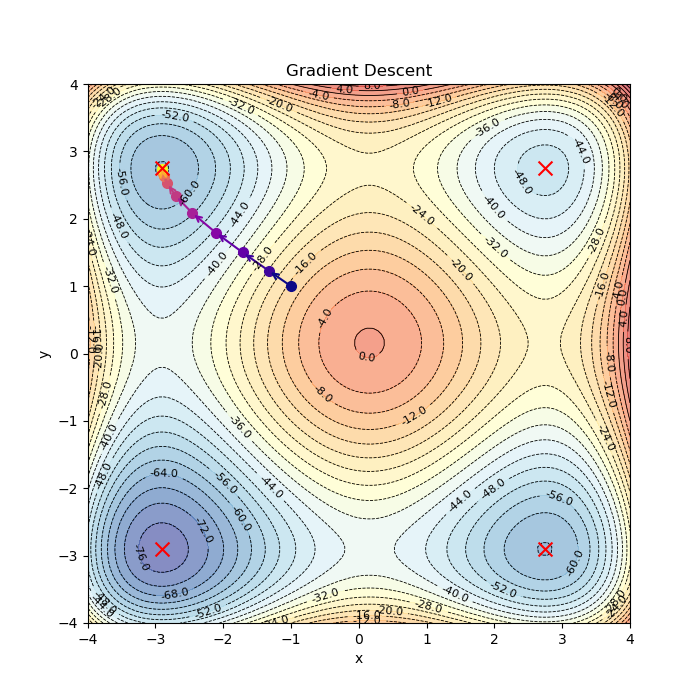

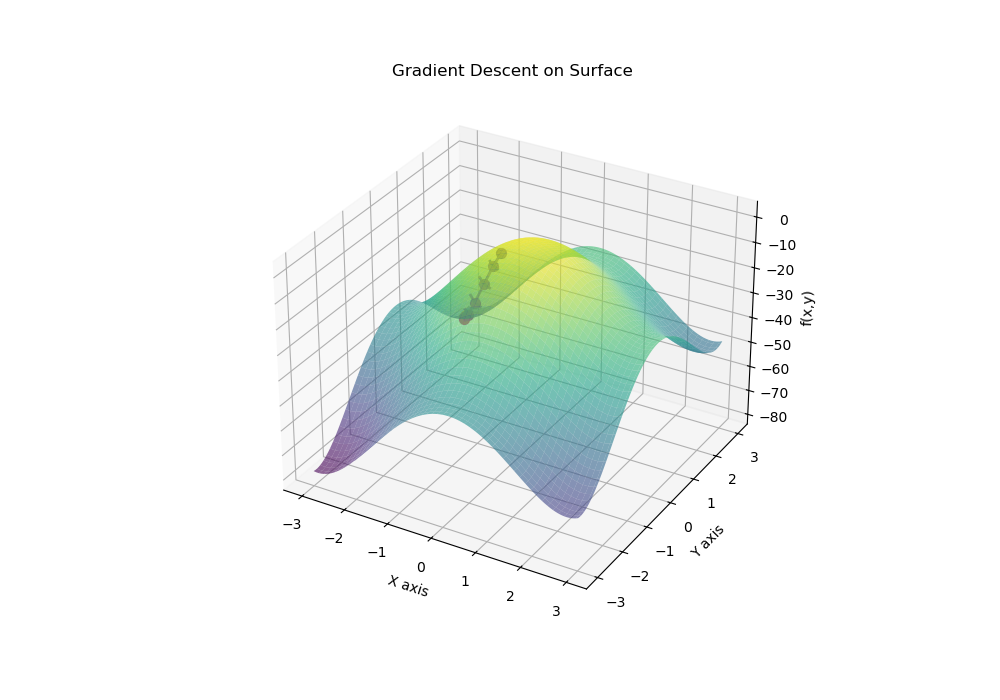

In [14]:
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr = 0.02, max_iters=10, initial_w=np.array([-1, 1]), verbose=True)
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")

x, y = (0.5, 1)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |   0.500000 |   1.000000 |  -5.250000 | -11.500000 |  -5.718750
        1 |   0.605000 |   1.230000 |  -6.737110 | -13.458266 |  -9.232480
        2 |   0.739742 |   1.499165 |  -8.526274 | -14.747907 | -14.085108
        3 |   0.910268 |   1.794123 | -10.555810 | -14.655843 | -20.094883
        4 |   1.121384 |   2.087240 | -12.621858 | -12.709419 | -26.610515
        5 |   1.373821 |   2.341429 | -14.295280 |  -9.290085 | -32.860404
        6 |   1.659727 |   2.527230 | -14.911553 |  -5.653384 | -38.474926
        7 |   1.957958 |   2.640298 | -13.815276 |  -2.932815 | -43.295668
        8 |   2.234263 |   2.698954 | -10.941631 |  -1.362988 | -46.886646
        9 |   2.453096 |   2.726214 |  -7.225646 |  -0.595652 | -48.925753
       10 |   2.597609 |   2.738127 |  -4.006640 |  -0.252692 | -49.750038


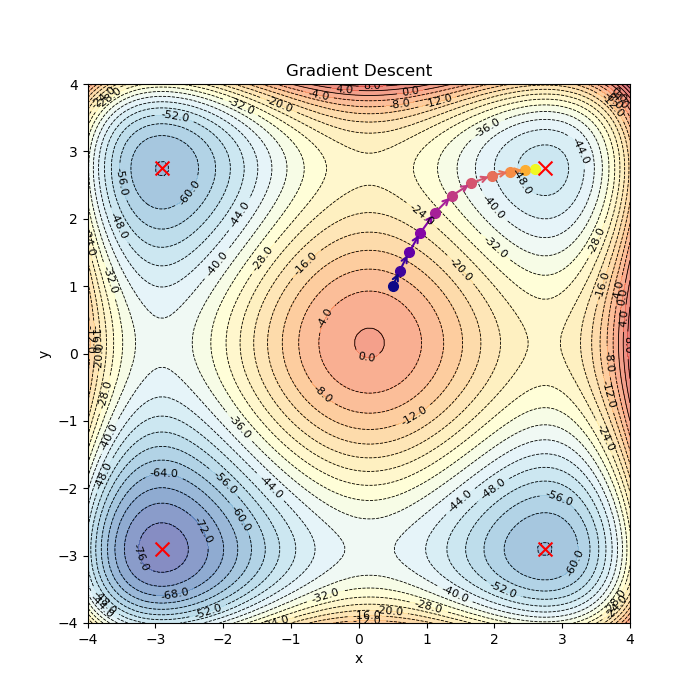

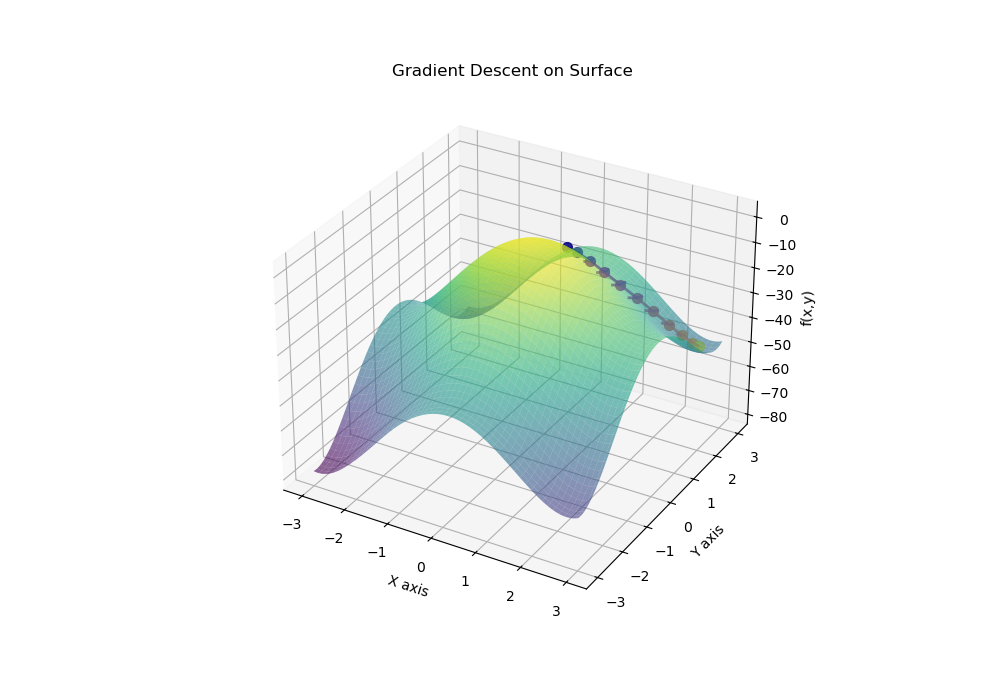

In [15]:
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr = 0.02, max_iters=10, initial_w=np.array([0.5, 1]), verbose=True)
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")

x, y = (-3, 0)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |  -3.000000 |   0.000000 |  -3.500000 |   2.500000 | -39.000000
        1 |  -2.930000 |  -0.050000 |  -0.927514 |   3.299750 | -39.298943
        2 |  -2.911450 |  -0.115995 |  -0.274841 |   4.352799 | -39.562615
        3 |  -2.905953 |  -0.203051 |  -0.083754 |   5.732072 | -40.002680
        4 |  -2.904278 |  -0.317692 |  -0.025732 |   7.518950 | -40.762722
        5 |  -2.903763 |  -0.468071 |  -0.007926 |   9.784042 | -42.065070
        6 |  -2.903605 |  -0.663752 |  -0.002443 |  12.535181 | -44.253033
        7 |  -2.903556 |  -0.914456 |  -0.000753 |  15.601904 | -47.792502
        8 |  -2.903541 |  -1.226494 |  -0.000232 |  18.433905 | -53.135260
        9 |  -2.903536 |  -1.595172 |  -0.000072 |  19.904687 | -60.273259
       10 |  -2.903535 |  -1.993266 |  -0.000022 |  18.553330 | -68.041403


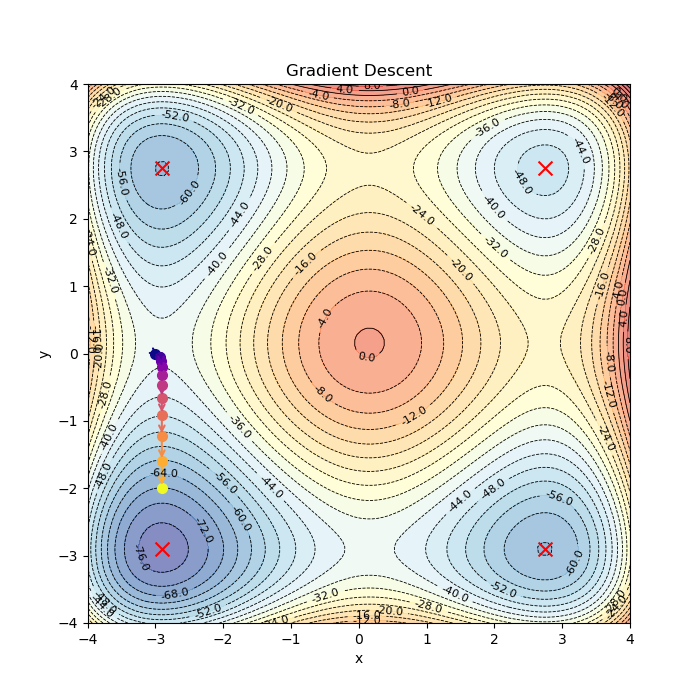

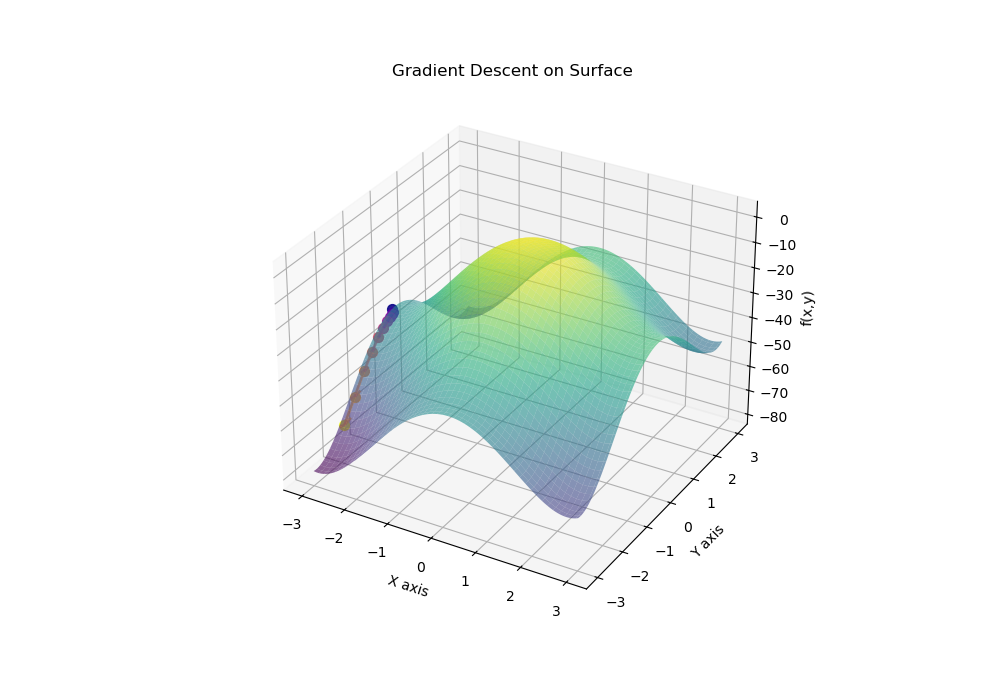

In [16]:
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr = 0.02, max_iters=10, initial_w=np.array([-3, 0]), verbose=True)
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")

x, y = (-3, 0.3)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |  -3.000000 |   0.300000 |  -3.500000 |  -2.246000 | -38.965950
        1 |  -2.930000 |   0.344920 |  -0.927514 |  -2.936650 | -39.236328
        2 |  -2.911450 |   0.403653 |  -0.274841 |  -3.826909 | -39.446159
        3 |  -2.905953 |   0.480191 |  -0.083754 |  -4.961610 | -39.783671
        4 |  -2.904278 |   0.579423 |  -0.025732 |  -6.381713 | -40.347092
        5 |  -2.903763 |   0.707058 |  -0.007926 |  -8.105963 | -41.273000
        6 |  -2.903605 |   0.869177 |  -0.002443 | -10.093559 | -42.751605
        7 |  -2.903556 |   1.071048 |  -0.000753 | -12.179477 | -45.007728
        8 |  -2.903541 |   1.314638 |  -0.000232 | -13.990099 | -48.212286
        9 |  -2.903536 |   1.594440 |  -0.000072 | -14.904145 | -52.286482
       10 |  -2.903535 |   1.892522 |  -0.000022 | -14.223686 | -56.673913


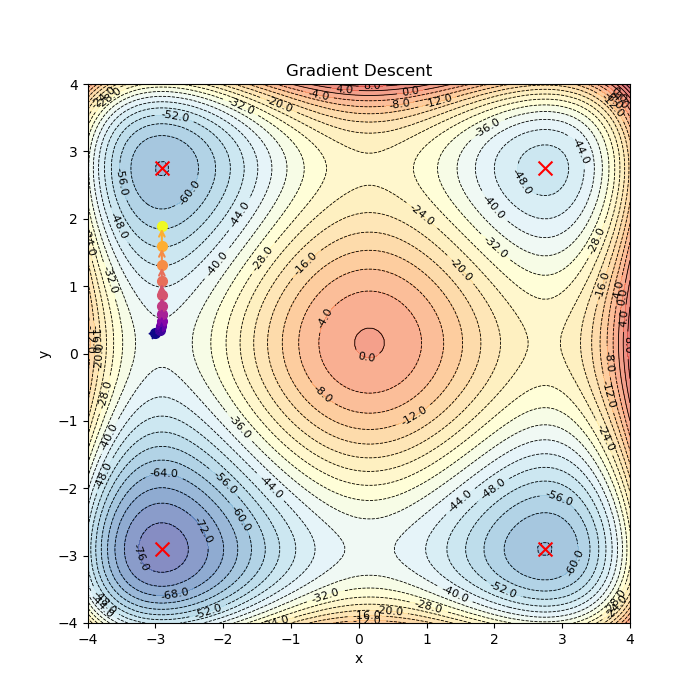

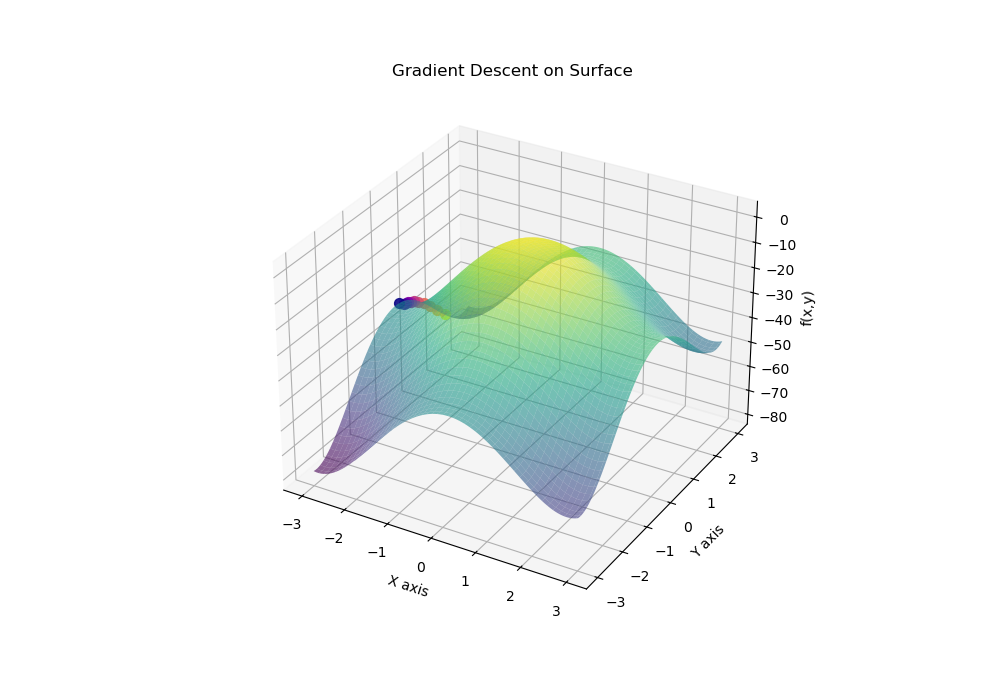

In [17]:
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr = 0.02, max_iters=10, initial_w=np.array([-3, 0.3]), verbose=True)
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")

x, y = (-3, -0.3)

Iteration |         w1 |         w2 |    grad_w1 |    grad_w2 |       Loss
--------------------------------------------------------------------------------
        0 |  -3.000000 |  -0.300000 |  -3.500000 |   7.246000 | -40.465950
        1 |  -2.930000 |  -0.444920 |  -0.927514 |   9.442573 | -41.830284
        2 |  -2.911450 |  -0.633771 |  -0.274841 |  12.131214 | -43.882170
        3 |  -2.905953 |  -0.876396 |  -0.083754 |  15.176066 | -47.206644
        4 |  -2.904278 |  -1.179917 |  -0.025732 |  18.093302 | -52.284467
        5 |  -2.903763 |  -1.541783 |  -0.007926 |  19.838599 | -59.212093
        6 |  -2.903605 |  -1.938555 |  -0.002443 |  18.946718 | -67.015254
        7 |  -2.903556 |  -2.317489 |  -0.000753 |  14.686484 | -73.503431
        8 |  -2.903541 |  -2.611219 |  -0.000232 |   8.670492 | -76.996201
        9 |  -2.903536 |  -2.784629 |  -0.000072 |   3.869155 | -78.097519
       10 |  -2.903535 |  -2.862012 |  -0.000022 |   1.406064 | -78.302934


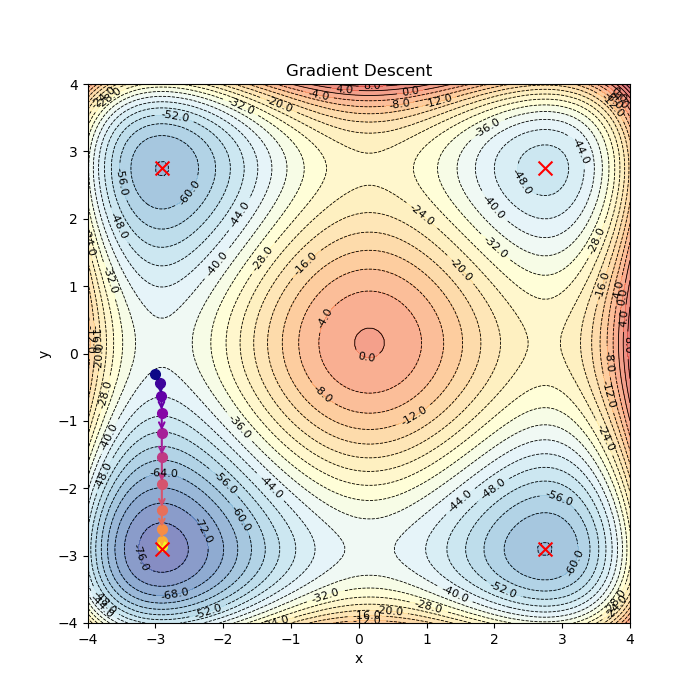

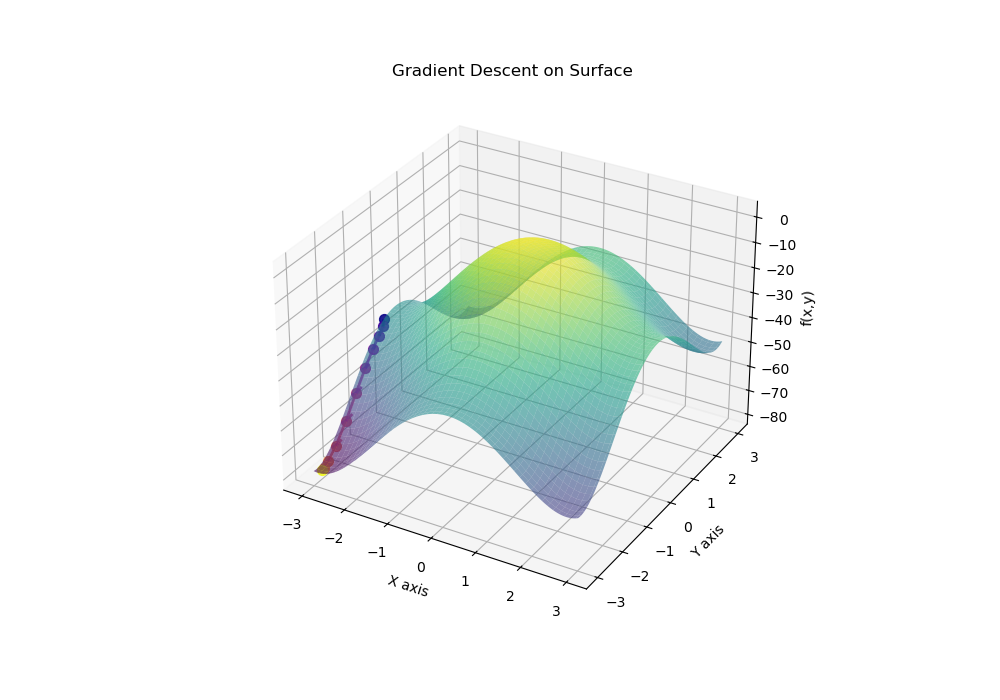

In [18]:
w_hist, loss_hist = gradient_descent(f2, grad_f2, lr = 0.02, max_iters=10, initial_w=np.array([-3, -0.3]), verbose=True)
x, y = sp.symbols('x y')
f_sym = 0.5*((x**4 - 16*x**2 + 5*x) + (y**4 - 16*y**2 + 5*y))
plot_gd_contour(f2, w_hist, limits=(-4, 4), levels=30, contour_cmap="RdYlBu_r", path_cmap="plasma", f_sym=f_sym)
plot_gd_3d(f2, w_hist, loss_hist, limits=(-3, 3), surface_cmap="viridis", path_cmap="plasma")